# Model Training

This notebook focuses on training and evaluating the baseline Logistic Regression model using the preprocessed application data.

The preprocessing steps were completed in '02_model_development.ipynb'. The saved training and validation datasets are loaded here to avoid repeating preprocessing.

## 6. Baseline Logistic Regression

The baseline model is trained to establish an initial performance benchmark. Its results will be used to evaluate whether later modeling approaches and feature engineering provide meaningful improvements.

### 6.1 Model Training

In [1]:
# import libraries
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

In [18]:
# import datasets
X_train_model = joblib.load('model_data/X_train_model.joblib')
X_valid_model = joblib.load('model_data/X_valid_model.joblib')

X_train_scaled = joblib.load('model_data/X_train_scaled.joblib')
X_valid_scaled = joblib.load('model_data/X_valid_scaled.joblib')

y_train = joblib.load('model_data/y_train.joblib')
y_valid = joblib.load('model_data/y_valid.joblib')

In [3]:
baseline_lr = LogisticRegression(max_iter = 1000)

baseline_lr.fit(X_train_scaled, y_train)

/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:911: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### 6.2.Probability Predictions

In [4]:
y_train_predict = baseline_lr.predict(X_train_scaled)
y_valid_predict = baseline_lr.predict(X_valid_scaled)

/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:911: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:911: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [5]:
y_train_proba = baseline_lr.predict_proba(X_train_scaled)[:, 1]
y_valid_proba = baseline_lr.predict_proba(X_valid_scaled)[:, 1]

/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:911: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:911: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


### 6.3 Discrimination Performance

In [6]:
train_auc = roc_auc_score(y_train, y_train_proba)
valid_auc = roc_auc_score(y_valid, y_valid_proba)

train_gini = 2*train_auc - 1
valid_gini = 2*valid_auc - 1

print('Train ROC-AUC:', train_auc)
print('Train GINI:', train_gini)
print('\n')
print('Validation ROC-AUC:', valid_auc)
print('Validation GINI:', valid_gini)

Train ROC-AUC: 0.7511534708949521
Train GINI: 0.5023069417899042


Validation ROC-AUC: 0.7505652161971323
Validation GINI: 0.5011304323942647


The baseline Logistic Regression achieved a ROC-AUC of 0.7512 on the training set and 0.7506 on the validation set. The corresponding Gini coefficients were 0.5023 and 0.5011.

The small train-validation gap indicates that discrimination performance is consistent across the two samples. However, this does not establish temporal stability or probability calibration, which will be assessed separately.

### 6.4 Precision-Recall Performance

In [7]:
train_ap = average_precision_score(y_train, y_train_proba)
valid_ap = average_precision_score(y_valid, y_valid_proba)

print('Train Average Precision:', train_ap)
print('Valid Average Precision:', valid_ap)


Train Average Precision: 0.22902851663785637
Valid Average Precision: 0.23557863810134075


The baseline model achieved an Average Precision of 0.2290 on the training set and 0.2356 on the validation set.

Both values are above the positive class prevalence of approximately 8.07%, indicating that the model provides useful ranking information for identifying clients with repayment difficulties. The small difference between training and validation performance does not indicate substantial deterioration on this split.

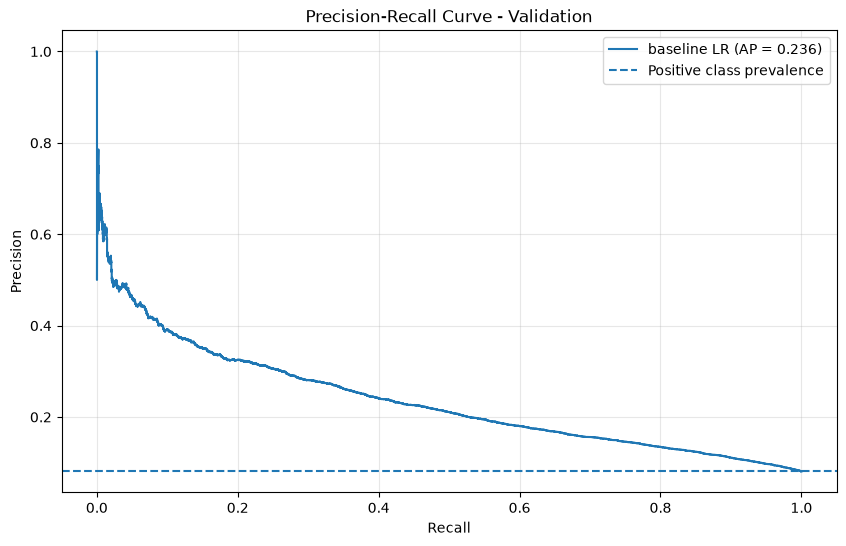

In [8]:
precision, recall, thresholds = precision_recall_curve(
    y_valid, y_valid_proba
)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(recall, precision, label=f'baseline LR (AP = {valid_ap:.3f})')
plt.axhline(y_valid.mean(), linestyle = '--', label = 'Positive class prevalence')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation')
plt.legend()
plt.grid(alpha = 0.3)

plt.show()



The Precision-Recall curve shows that precision decreases as recall increases. The model achieves higher precision when focusing on a smaller group of clients with the highest predicted risk, while identifying a larger proportion of positive cases requires accepting more false positives.

The curve remains above the positive class prevalence baseline, supporting the model's ability to rank clients with repayment difficulties. The appropriate classification threshold will depend on the business objective and the relative costs of false positives and false negatives.

### 6.5 Classification Performance

In [9]:
threshold = 0.5

y_valid_pred = (y_valid_proba >= threshold).astype(int)

In [10]:
cm = confusion_matrix(y_valid, y_valid_pred)
print(cm)

[[56499    39]
 [ 4906    59]]


In [11]:
print('Recall:', recall_score(y_valid, y_valid_pred))
print('Precision:', precision_score(y_valid, y_valid_pred))
print('F1_score:', f1_score(y_valid, y_valid_pred))

Recall: 0.011883182275931522
Precision: 0.6020408163265306
F1_score: 0.023306340114556588


In [12]:
print('Observed rate:', y_valid.mean())
print('Average predicted probability:', y_valid_proba.mean())

Observed rate: 0.08072776937710356
Average predicted probability: 0.08048154258389427


The observed positive class rate is 8.073%, while the average predicted probability is 8.048%. The small difference indicates no substantial aggregate underestimation or overestimation of risk.

However, aggregate agreement does not guarantee calibration across different risk levels. The low recall at a threshold of 0.5 reflects the classification decision rule and should be considered separately from probability calibration.

In [ ]:
thresholds = np.linspace(0.1, 0.5, 9)
results = []

for threshold in thresholds:
    y_pred = (y_valid_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()
    results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_valid, y_pred),
        'Recall': recall_score(y_valid, y_pred),
        'F1 score': f1_score(y_valid, y_pred)
        })
    
threshold_results = pd.DataFrame(results)
threshold_results

,Threshold,Precision,Recall,F1 score,Average Precision
0,0.10,0.181987,0.592548,0.278453,0.140729
1,0.15,0.239200,0.407049,0.301327,0.145234
2,0.20,0.291013,0.276536,0.283590,0.138879
3,0.25,0.330477,0.178651,0.231926,0.125346
4,0.30,0.377483,0.114804,0.176062,0.114796
5,0.35,0.425000,0.071903,0.122997,0.105482
6,0.40,0.481651,0.042296,0.077763,0.097685
7,0.45,0.497797,0.022759,0.043529,0.090220
8,0.50,0.602041,0.011883,0.023306,0.086923


The threshold analysis shows a clear trade-off between Precision and Recall. At a threshold of 0.10, the model detects 59.25% of clients with repayment difficulties, with a Precision of 18.20%. At 0.15, Recall decreases to 40.70%, while Precision improves to 23.92%.

If the business prioritizes detecting clients with repayment difficulties, thresholds of 0.10 and 0.15 are reasonable candidates for further evaluation. However, a lower threshold also increases false positives, which may lead to unnecessary reviews or the rejection of potentially profitable clients.

The final threshold should therefore depend on the model's intended use, the costs of false positives and false negatives, and business constraints. No operational threshold is selected at this stage.

### 6.6 Baseline Conclusion

The baseline Logistic Regression achieved a validation ROC-AUC of 0.7506, Gini of 0.5011, and Average Precision of 0.2356. The small train-validation performance gap suggests that discrimination is relatively consistent across the two samples.

The model shows useful ranking ability, but classification performance depends strongly on the selected threshold. Lower thresholds improve Recall at the cost of more false positives. The average predicted probability is also close to the observed positive class rate, although calibration across risk levels has not yet been assessed.

This baseline will be used as a benchmark for further feature analysis and model development. No final operational threshold has been selected.

## 7. WOE and Information Value
WOE analysis is used to examine how the distribution of positive and negative clients differs across feature groups. The binning rules and WOE values will be learned from the training data only and then applied to validation data.

### 7.1 WOE — Weight of Evidence

In [23]:
data_woe = pd.read_csv('data/preprocessed_data.csv')

X_train_woe_raw = data_woe.loc[y_train.index].drop(
    columns = ['SK_ID_CURR', 'TARGET']
)

X_valid_woe_raw = data_woe.loc[y_valid.index].drop(
    columns=['SK_ID_CURR', 'TARGET']
)

print(X_train_woe_raw.shape)
print(X_valid_woe_raw.shape)

(246008, 126)
(61503, 126)
